In [1]:
import en_core_web_lg
import spacy
import numpy as np
import sklearn.cluster as clust
import sklearn.model_selection as mod
import csv
from matplotlib import pyplot as plt
nlp = en_core_web_lg.load()


In [2]:
reds = []
greens = []

with open("RED.csv", 'r') as csvfile:
    reader = csv.reader(csvfile)
    for row in reader:
        reds.append(row[1])

with open("GREEN.csv", 'r') as csvfile:
    reader = csv.reader(csvfile)
    for row in reader:
        greens.append(row[1])



['A Car Crash ', 'A Cheap Motel ', 'A Crawl Space ', 'A Flat Tire ', 'A High School Bathroom ', 'A Honeymoon ', 'A Locker Room ', 'A Morgue ', 'A Sunrise ', 'A Sunset ', 'A Used Car Lot ', 'Abraham Lincoln ', 'Adolph Hitler ', 'Albert Einstein ', 'Alfred Hitchcock ', 'Americans ', 'Andy Warhol ', 'Anne Frank ', 'Antarctica ', 'Apples ', "At My Parent's House ", 'Atomic Bombs ', 'Attack On Pearl Harbor ', 'Babe Ruth ', 'Baby Showers ', 'Bad Dogs ', 'Baked Potatoes ', 'Bangkok ', 'Barfing ', 'Barney ', 'Bart Simpson ', 'Beethoven ', 'Being In Love ', 'Berlin ', 'Bill Clinton ', 'Bill Gates ', 'Billboards ', 'Black Holes ', 'Blizzard ', 'Blood ', 'Body Surfing ', 'Bonbons ', 'Brad Pitt ', 'Bubbles ', 'Bungee Jumping ', 'Cactus ', 'California ', 'Canada ', 'Canadians ', 'Captain Kirk ', 'Car Horns ', 'Carl Sagan ', 'Celine Dion ', 'Chains ', 'Challenger Explosion ', 'Charging Rhinos ', 'Cher ', 'Chicago ', 'Chimpanzees ', 'China ', 'Cigarettes ', 'Cinco de Mayo ', 'Cindy Crawford ', 'Clark

In [3]:
redVecs = []
greenVecs = []

for red in reds:
    redVecs.append(nlp(red).vector)

for green in greens:
    greenVecs.append(nlp(green).vector)

redVecs = np.array(redVecs)
greenVecs = np.array(greenVecs)


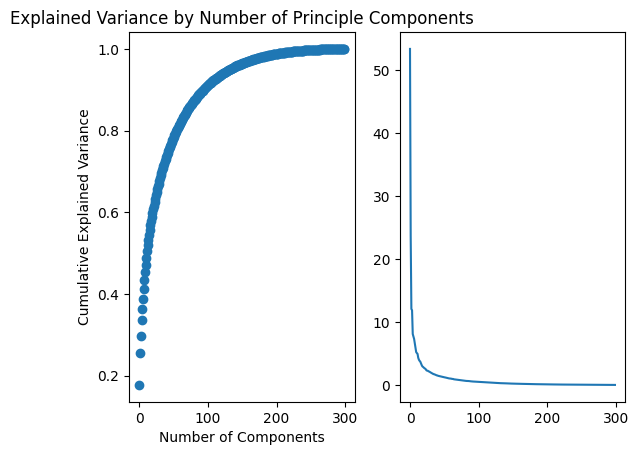

Number of components to explain 0.7 variance: 34


In [4]:
#PCA

dataset = greenVecs

from sklearn.decomposition import PCA
from sklearn import preprocessing

thresh = 0.7

X = preprocessing.StandardScaler().fit_transform(dataset)

pca = PCA(n_components=X.shape[1])
pca.fit(X)

var = pca.explained_variance_ratio_
cumVar = np.cumsum(var)


fig = plt.figure()
axs = fig.subplots(1,2)

axs[0].scatter(np.arange(pca.n_components_),cumVar)
axs[0].set_title("Explained Variance by Number of Principle Components")
axs[0].set_xlabel("Number of Components")
axs[0].set_ylabel("Cumulative Explained Variance")
# ax.set_xlim((-5, 5))
# ax.set_ylim((-5, 5))
# ax.set_zlim((-5, 5))

axs[1].plot(pca.explained_variance_)
plt.show()

num_components = np.argmax(cumVar >= thresh) + 1
print(f"Number of components to explain {thresh} variance: {num_components}")
pca = PCA(n_components=num_components)
X_reduced = pca.fit_transform(X)

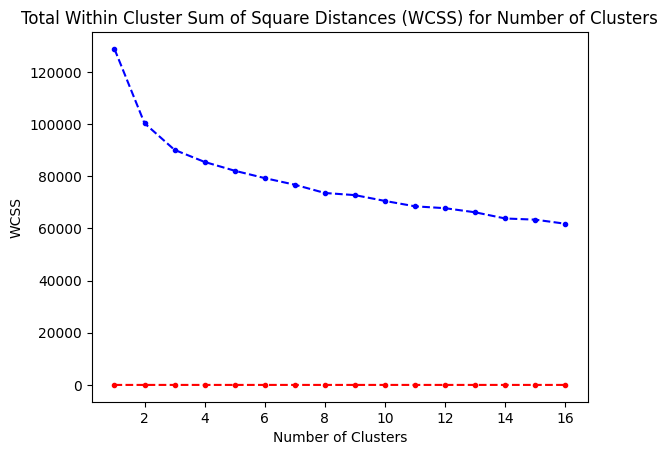

In [5]:
#KMEANS
import time

#ELBOW TEST
# redTrain, redTest = mod.train_test_split(redVecs)
# greenTrain, greenTest = mod.train_test_split(greenVecs)


wcss = []
times = []

for i in range(1,X_reduced.shape[1]//2):
    run = time.time()

    model = clust.KMeans(n_clusters=i, n_init=10, max_iter=1000)
    model.fit(X_reduced)
    wcss.append(model.inertia_)
    times.append(time.time() - run)

fig = plt.figure()
ax = fig.add_subplot()
ax.plot(np.arange(1,len(wcss)+1),wcss, 'b.--', np.arange(1, len(times)+1), times, 'r.--')
#ax.scatter(np.arange(1, len(times)+1), times, linewidths=1)
ax.set_title("Total Within Cluster Sum of Square Distances (WCSS) for Number of Clusters")
ax.set_xlabel("Number of Clusters")
ax.set_ylabel("WCSS")
# ax.set_xlim((-5, 5))
# ax.set_ylim((-5, 5))
# ax.set_zlim((-5, 5))
plt.show()    


Best K: 2 with num components = 50; Silhouette score of 0.3423635959625244


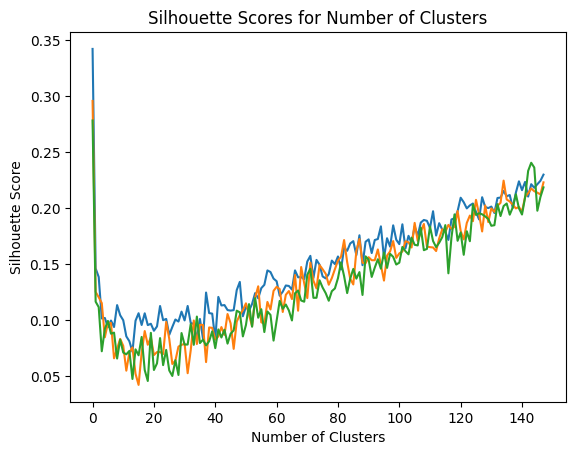

KMeans(algorithm='elkan', max_iter=1000, n_clusters=2, n_init=10)

In [35]:
#KMEANS Silhouette Analysis
from sklearn.metrics import silhouette_score

num_components = [50, 100, 150]

silScores = [[] for i in num_components]
bestK = None
bestScore = -1
comp = None

for k, j in enumerate(num_components):
    pca = PCA(n_components=j)
    X_reduced = pca.fit_transform(X)
    for i in range(2,150):

        model = clust.KMeans(n_clusters=i, n_init=10, max_iter=1000, algorithm='elkan')
        model.fit(X_reduced)
        silScores[k].append(silhouette_score(X_reduced, model.labels_))
        
        if (silScores[k][-1] > bestScore):
            bestK = i
            bestScore = silScores[k][-1]
            comp = j

print(f'Best K: {bestK} with num components = {comp}; Silhouette score of {bestScore}')

fig = plt.figure()
ax = fig.add_subplot()
ax.plot(np.array(silScores).T)
#ax.scatter(np.arange(1, len(times)+1), times, linewidths=1)
ax.set_title("Silhouette Scores for Number of Clusters")
ax.set_xlabel("Number of Clusters")
ax.set_ylabel("Silhouette Score")
fig.legend()
# ax.set_xlim((-5, 5))
# ax.set_ylim((-5, 5))
# ax.set_zlim((-5, 5))
plt.show()

model = clust.KMeans(n_clusters=bestK, n_init=10, max_iter=1000, algorithm='elkan')
model.fit(X_reduced)

c:\Users\malco\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_affinity_propagation.py:143: ConvergenceWarning: Affinity propagation did not converge, this model may return degenerate cluster centers and labels.
  warnings.warn(


Best number of components: 100; Silhouette score of 0.17442208528518677
Best number of components: 25; Calinski Harabasz score of 26.942095184193594


c:\Users\malco\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_affinity_propagation.py:143: ConvergenceWarning: Affinity propagation did not converge, this model may return degenerate cluster centers and labels.
  warnings.warn(


Best number of components: 125; Davies-Bouldin score of 1.0765005059537696


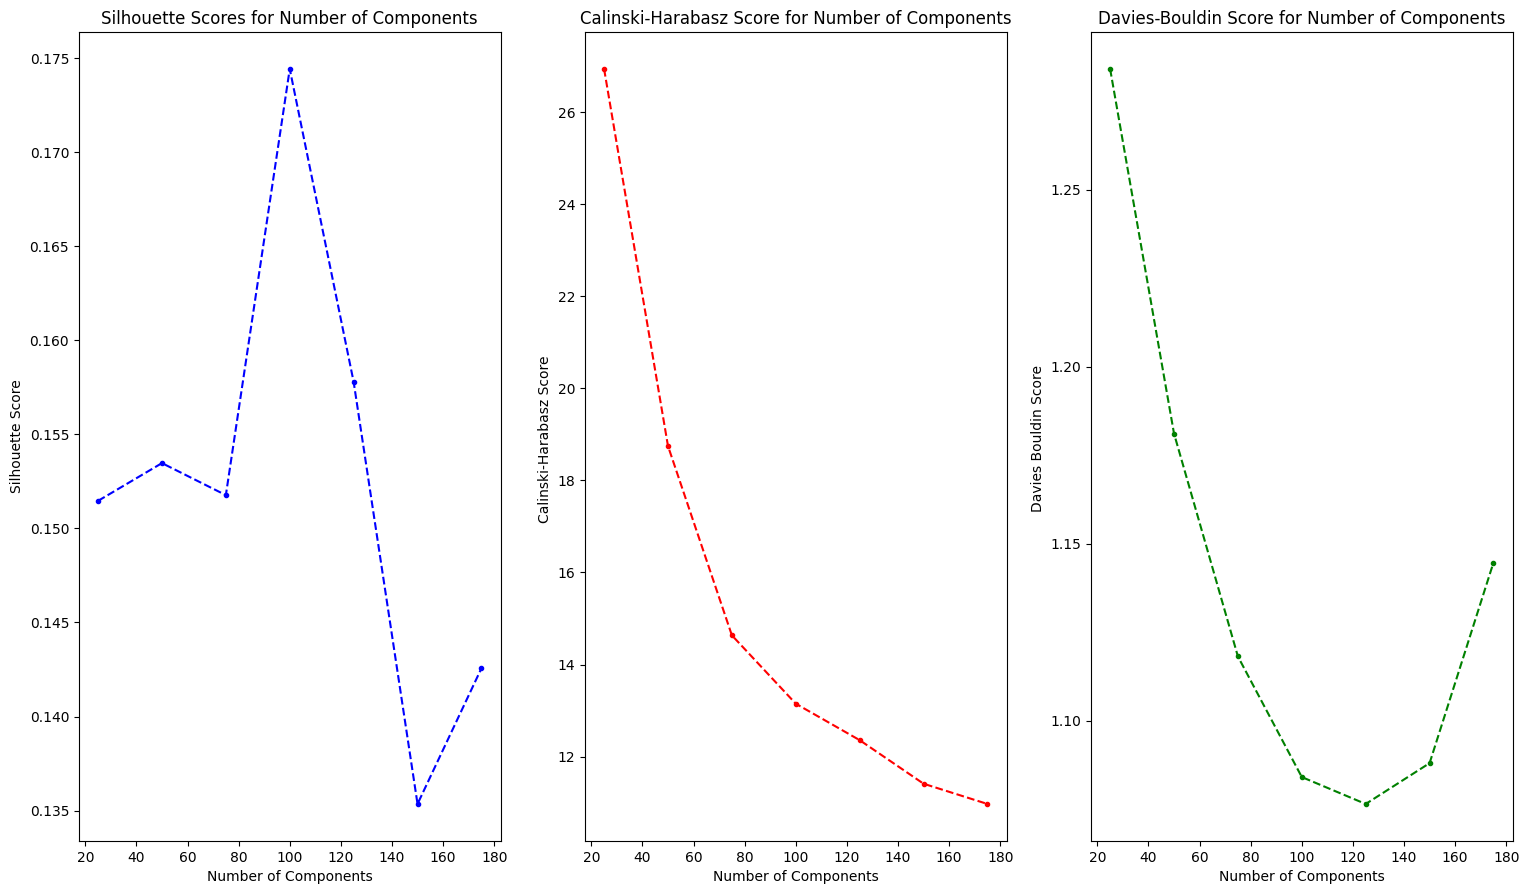

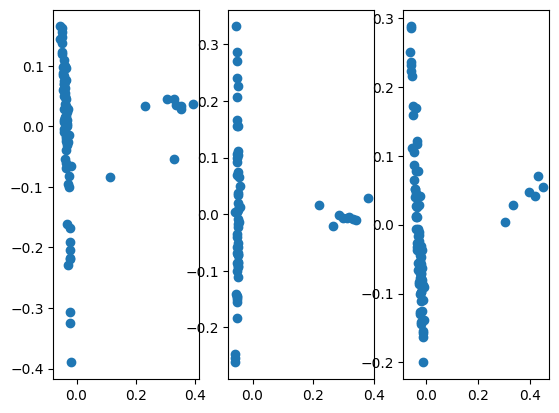

In [50]:
#Affinity Propogation Silhouette Analysis
from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score

num_components = np.arange(25, 200, 25)

silScores = []
chScores = []
dbScores = []
bestScore = -1
components = None
bestScoreCH = -1
compCH = None
bestScoreDB = np.inf
compDB = None

for j in num_components:
    pca = PCA(n_components=j)
    X_reduced = pca.fit_transform(X)
    model = clust.AffinityPropagation(max_iter=1000, convergence_iter=200).fit(X_reduced)
    silScores.append(silhouette_score(X_reduced, model.labels_))
    
    if (silScores[-1] > bestScore):
        bestScore = silScores[-1]
        components= j

print(f'Best number of components: {components}; Silhouette score of {bestScore}')

for j in num_components:
    pca = PCA(n_components=j)
    X_reduced = pca.fit_transform(X)
    model = clust.AffinityPropagation(max_iter=1000, convergence_iter=200).fit(X_reduced)
    chScores.append(calinski_harabasz_score(X_reduced, model.labels_))
    
    if (chScores[-1] > bestScoreCH):
        bestScoreCH = chScores[-1]
        compCH= j

print(f'Best number of components: {compCH}; Calinski Harabasz score of {bestScoreCH}')

for j in num_components:
    pca = PCA(n_components=j)
    X_reduced = pca.fit_transform(X)
    model = clust.AffinityPropagation(max_iter=1000, convergence_iter=200).fit(X_reduced)
    dbScores.append(davies_bouldin_score(X_reduced, model.labels_))
    
    if (dbScores[-1] < bestScoreDB):
        bestScoreDB = dbScores[-1]
        compDB= j

print(f'Best number of components: {compDB}; Davies-Bouldin score of {bestScoreDB}')

fig, axs = plt.subplots(1,3)
axs[0].plot(num_components, silScores, 'b.--', label='Silhouette')
axs[0].set_title("Silhouette Scores for Number of Components")
axs[0].set_xlabel("Number of Components")
axs[0].set_ylabel("Silhouette Score")

axs[1].plot(num_components, chScores, 'r.--', label='CH')
axs[1].set_title("Calinski-Harabasz Score for Number of Components")
axs[1].set_xlabel("Number of Components")
axs[1].set_ylabel("Calinski-Harabasz Score ")

axs[2].plot(num_components, dbScores, 'g.--', label='DB')
axs[2].set_title("Davies-Bouldin Score for Number of Components")
axs[2].set_xlabel("Number of Components")
axs[2].set_ylabel("Davies Bouldin Score ")

fig.set_size_inches(18.5, 10.5)

plt.show()

pca = PCA(n_components=components)
X_reduced = pca.fit_transform(X)
model = clust.AffinityPropagation(max_iter=1000, convergence_iter=200).fit(X_reduced)

from sklearn import manifold

fig, axs = plt.subplots(1, 3)

node_position_model = manifold.LocallyLinearEmbedding(
    n_components=2, eigen_solver="dense", n_neighbors=6
)

embedding = node_position_model.fit_transform(model.cluster_centers_)
axs[0].scatter(embedding[:,0], embedding[:,1])

pca = PCA(n_components=compCH)
X_reduced = pca.fit_transform(X)
model = clust.AffinityPropagation(max_iter=1000, convergence_iter=200).fit(X_reduced)

embedding = node_position_model.fit_transform(model.cluster_centers_)
axs[1].scatter(embedding[:,0], embedding[:,1])

pca = PCA(n_components=compDB)
X_reduced = pca.fit_transform(X)
model = clust.AffinityPropagation(max_iter=1000, convergence_iter=200).fit(X_reduced)

embedding = node_position_model.fit_transform(model.cluster_centers_)
axs[2].scatter(embedding[:,0], embedding[:,1])

fig.set_size_inches(18.5, 10.5)

plt.show()

In [67]:
red_norm = preprocessing.StandardScaler().fit_transform(redVecs)
green_norm = preprocessing.StandardScaler().fit_transform(greenVecs)


pca = PCA(n_components=100)
red_reduced = pca.fit_transform(red_norm)
green_reduced = pca.fit_transform(green_norm)
modelRed = clust.AffinityPropagation(max_iter=1000, convergence_iter=200).fit(red_reduced)
modelGreen = clust.AffinityPropagation(max_iter=1000, convergence_iter=200).fit(green_reduced)


red_list = []

for red in modelRed.cluster_centers_:
    smallest = np.inf
    green_ind = None
    for i, green in enumerate(green_reduced):
        dist = np.linalg.norm(green - red)
        if dist < smallest:
            smallest = dist
            green_ind = i

    red_list.append(green_ind)

green_list = []

for green in modelGreen.cluster_centers_:
    smallest = np.inf
    red_ind = None
    for i, red in enumerate(green_reduced):
        dist = np.linalg.norm(red - green)
        if dist < smallest:
            smallest = dist
            red_ind = i

    green_list.append(red_ind)

from collections import Counter  
def sort_by_frequency(lst):  
    freq_dict = Counter(lst)  
    return sorted(lst, key=lambda x: (-freq_dict[x], x))  

closestGreens = sort_by_frequency(red_list)
closestReds = sort_by_frequency(green_list)
print(closestGreens)
#print(closestReds)
#print(np.array(greens)[closestGreens])
print(np.array(reds)[np.where(modelRed.labels_ == 105)[0]])
print(np.array(reds)[closestReds])

print(np.array(greens)[red_list])
print(np.array(reds)[green_list])

[105, 105, 105, 105, 105, 105, 105, 105, 105, 346, 346, 346, 346, 346, 346, 219, 219, 219, 219, 219, 35, 35, 35, 35, 130, 130, 130, 130, 403, 403, 403, 403, 7, 7, 7, 32, 32, 32, 59, 59, 59, 72, 72, 72, 114, 114, 114, 165, 165, 165, 186, 186, 186, 229, 229, 229, 260, 260, 260, 302, 302, 302, 597, 597, 597, 43, 43, 48, 48, 83, 83, 128, 128, 142, 142, 240, 240, 250, 250, 256, 256, 266, 266, 273, 273, 299, 299, 323, 323, 478, 478, 588, 588, 0, 10, 15, 23, 24, 47, 55, 62, 70, 74, 88, 96, 106, 112, 116, 122, 129, 132, 147, 159, 175, 176, 205, 235, 236, 245, 272, 278, 280, 282, 306, 319, 321, 352, 356, 359, 410, 434, 456, 468, 477, 485, 486, 501, 515, 536, 539, 572, 589]
['A Cheap Motel ' 'Getting A Hug ' 'Giving A Hug ' 'Running A Marathon '
 'Taking A Bath ' 'A Bad Haircut ' 'Buying A House ' 'Having A Baby '
 'Reading A Good Book ' 'Looking For A Job ' 'A Few Good Men '
 'A French Maid ' 'A Little White Lie ' 'A Million Dollars '
 'Getting A Haircut ' 'Getting A Shot ' 'Painting A Fence '


: 

In [ ]:
#Which word vectors are the closest to the centroids?
from sklearn.metrics import pairwise_distances_argmin_min
import spacy.vectors
#indices of closest points
closest, _ = pairwise_distances_argmin_min(model.cluster_centers_, X_reduced)



[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178  91
 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196
 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214
 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232
 233 234 235 236 237 238 239 240 241 242 243 244 24

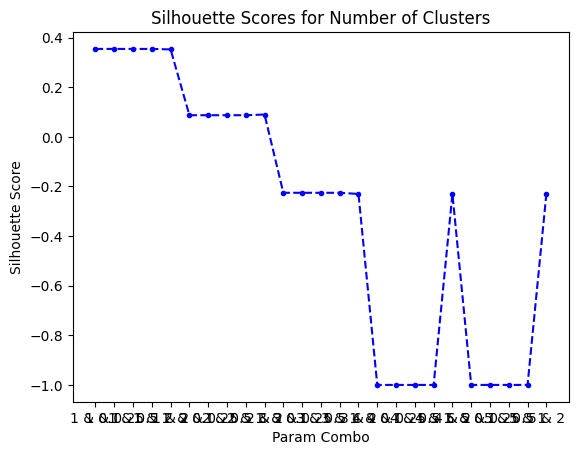

K with best arams: 503 with eps = 0.1, min. samples = 1; Silhouette score of 0.3545750677585602


In [ ]:
#DBSCAN Silhouette Analysis
from sklearn.metrics import silhouette_score
import itertools

silScores = []
bestK = None
bestSamps = None
bestScore = -1
bestEps = None
eps = [0.1, 0.25,0.5,1, 2]
samps = [1, 2, 3, 4, 5]
for i in samps:
    for j in eps:

        model = clust.DBSCAN(eps=j, min_samples=i)
        model.fit(X_reduced)
        print(model.labels_)
        try:
            silScores.append(silhouette_score(X_reduced, model.labels_))

            if (silScores[-1] > bestScore):
                bestK = len(np.unique(model.labels_))
                bestEps = j
                bestSamps = i
                bestScore = silScores[-1]
        except Exception as e:
            silScores.append(-1)

fig = plt.figure()
ax = fig.add_subplot()
ax.plot([f'{samp} &'+f' {e}' for samp in samps for e in eps], silScores, 'b.--')
#ax.scatter(np.arange(1, len(times)+1), times, linewidths=1)
ax.set_title("Silhouette Scores for Number of Clusters")
ax.set_xlabel("Param Combo")
ax.set_ylabel("Silhouette Score")
# ax.set_xlim((-5, 5))
# ax.set_ylim((-5, 5))
# ax.set_zlim((-5, 5))
plt.show()    


    
print(f'K with best arams: {bestK} with eps = {bestEps}, min. samples = {bestSamps}; Silhouette score of {bestScore}')

